In [1]:
import pandas as pd 
df = pd.read_csv('presales_data_sample.csv')
df


,input_row_key,input_company_name,input_main_country_code,input_main_country,input_main_region,input_main_city,input_main_postcode,input_main_street,input_main_street_number,veridion_id,...,twitter_url,instagram_url,linkedin_url,ios_app_url,android_app_url,youtube_url,tiktok_url,technologies,created_at,last_updated_at
0,0,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,PK,Pakistan,Sindh,Karachi,NaN,NaN,NaN,26e22210-93e5-11eb-b997-8dd98d09cf25,...,NaN,NaN,http://www.linkedin.com/company/mnet-services-...,NaN,NaN,NaN,NaN,web servers: apache http server - 2 | javascri...,2020-02-25T14:47:51.000Z,2024-11-29T04:18:00.109Z
1,0,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,PK,Pakistan,Sindh,Karachi,NaN,NaN,NaN,01004641-1dd8-11ef-9268-316fc8e174dd,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-05-29T16:24:11.019Z,2025-04-20T15:03:24.026Z
2,0,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,PK,Pakistan,Sindh,Karachi,NaN,NaN,NaN,8266efc1-13e7-11ec-aa14-7bf90e1e10f1,...,https://twitter.com/Network24seven%20,NaN,https://www.linkedin.com/company/51633612%20%20,NaN,NaN,NaN,NaN,NaN,2021-09-12T05:28:48.000Z,2025-03-18T23:08:37.059Z
3,0,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,PK,Pakistan,Sindh,Karachi,NaN,NaN,NaN,0183f0b2-93e5-11eb-be5a-4f810ab55f2e,...,https://twitter.com/emeriosoft,NaN,https://www.linkedin.com/company/emeriosoft,NaN,NaN,NaN,NaN,miscellaneous: popper | maps: google maps | pr...,2020-05-03T12:33:22.000Z,2025-03-31T16:16:58.462Z
4,0,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,PK,Pakistan,Sindh,Karachi,NaN,NaN,NaN,87bb7cde-93e4-11eb-8474-3bbe2d07207d,...,https://twitter.com/AsiaticPR,https://www.instagram.com/asiaticpublicrelations/,https://www.linkedin.com/company/asiaticpublic...,NaN,NaN,https://www.youtube.com/channel/UClKgHvHIuOu4K...,NaN,miscellaneous: babel | javascript libraries: c...,2020-02-19T03:58:25.000Z,2024-11-25T11:35:47.963Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2946,99,Comba Technologies Sdn. Bhd.,MY,Malaysia,Selangor,Subang Jaya,47650,Jalan USJ 25/1B,NaN,00af1484-93e5-11eb-aa66-9b8d95e2171b,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-12-05T18:12:15.000Z,2025-04-03T01:54:04.425Z
2947,99,Comba Technologies Sdn. Bhd.,MY,Malaysia,Selangor,Subang Jaya,47650,Jalan USJ 25/1B,NaN,00eac49f-918f-11ed-8cca-6b54a7dd36ad,...,NaN,https://www.instagram.com/mydialysis/,NaN,NaN,https://play.google.com/store/apps/details?id=...,NaN,NaN,web servers: litespeed | javascript libraries:...,2023-01-08T16:25:46.000Z,2025-04-19T03:16:59.073Z
2948,99,Comba Technologies Sdn. Bhd.,MY,Malaysia,Selangor,Subang Jaya,47650,Jalan USJ 25/1B,NaN,01fb2fa2-a7fa-11ef-9e6b-b90a330e89d5,...,NaN,https://www.instagram.com/cmbooststudio/,NaN,NaN,NaN,NaN,NaN,NaN,2024-05-02T23:25:07.152Z,2025-04-21T03:29:20.141Z
2949,99,Comba Technologies Sdn. Bhd.,MY,Malaysia,Selangor,Subang Jaya,47650,Jalan USJ 25/1B,NaN,0fa7533d-93e5-11eb-b997-8dd98d09cf25,...,NaN,NaN,https://www.linkedin.com/showcase/combausa,NaN,NaN,https://www.youtube.com/channel/UCqOIMCMBwU06N...,NaN,javascript libraries: core-js | widgets: twitt...,2019-11-24T10:54:58.000Z,2025-03-27T08:56:47.434Z


Functia principala care se ocupa de calcularea scorului si aplicarea ei peste dataframe.

In [2]:
from thefuzz import fuzz
import pandas as pd

def calculate_score(row):
    score = 0
    
    name_input = str(row['input_company_name']).lower()
    
    score_name = fuzz.token_sort_ratio(name_input, str(row['company_name']).lower())
    score_legal = fuzz.token_sort_ratio(name_input, str(row['company_legal_names']).lower())
    score_commercial = fuzz.token_sort_ratio(name_input, str(row['company_commercial_names']).lower())
    
    name_similarity = max(score_name, score_legal, score_commercial)
    
    input_country = str(row['input_main_country_code']).strip().upper()
    output_country = str(row['main_country_code']).strip().upper()
    
    if input_country == output_country:
        score += 30
        score += (name_similarity / 100) * 40
    else:
        score += (name_similarity / 100) * 40 * 0.2
    
    if str(row['input_main_city']).lower() == str(row['main_city']).lower():
        score += 10
    elif str(row['input_main_city']).lower() in str(row['main_city']).lower() or str(row['main_city']).lower() in str(row['input_main_city']).lower():
        score += 5
   
    if str(row['input_main_region']).lower() == str(row['main_region']).lower():
        score += 5
        
    if str(row['input_main_postcode']) == str(row['main_postcode']):
        score += 5
        
    if str(row['input_main_street']).lower() in str(row['main_street']).lower():
        score += 7
        
    if str(row['input_main_street_number']) == str(row['main_street_number']):
        score += 3
        
    return score

df['score'] = df.apply(calculate_score, axis=1)

best_matches = df.sort_values(by=['input_row_key', 'score'], ascending=[True, False])
best_matches = best_matches.drop_duplicates(subset=['input_row_key'], keep='first')

best_matches.to_csv('best_selection.csv', index=False)

In [4]:
import pandas as pd
dfb = pd.read_csv('best_selection.csv')
dfb

,input_row_key,input_company_name,input_main_country_code,input_main_country,input_main_region,input_main_city,input_main_postcode,input_main_street,input_main_street_number,veridion_id,...,instagram_url,linkedin_url,ios_app_url,android_app_url,youtube_url,tiktok_url,technologies,created_at,last_updated_at,score
0,0,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,PK,Pakistan,Sindh,Karachi,NaN,NaN,NaN,26e22210-93e5-11eb-b997-8dd98d09cf25,...,NaN,http://www.linkedin.com/company/mnet-services-...,NaN,NaN,NaN,NaN,web servers: apache http server - 2 | javascri...,2020-02-25T14:47:51.000Z,2024-11-29T04:18:00.109Z,79.8
1,1,2OPERATE A/S,DK,Denmark,North Denmark Region,Aalborg,9220,Niels Jernes Vej,10,8b99ef83-93e4-11eb-b997-8dd98d09cf25,...,NaN,https://www.linkedin.com/company/2operate-as,NaN,NaN,NaN,NaN,javascript libraries: lodash | javascript libr...,2020-02-17T15:56:51.000Z,2025-03-28T15:16:32.101Z,95.0
2,2,3 STEP IT A/S,DK,Denmark,Region Of Southern Denmark,Tønder Municipality,NaN,NaN,NaN,45309031-f8ab-11ed-89fe-613148a94f23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-05-22T14:15:04.005Z,2025-04-16T15:47:06.888Z,70.0
3,3,3 STEP IT AS,NO,Norway,Oslo,Oslo,0167,Wergelandsveien,7,08f48bc2-72c9-11ec-96d1-1d653dff9d1b,...,NaN,NaN,NaN,NaN,NaN,NaN,miscellaneous: http/3 | web servers: litespeed,2022-01-08T19:57:26.000Z,2024-11-04T18:08:47.000Z,65.2
4,4,3 Step IT Sweden AB,SE,Sweden,Östergötland County,Linköping,581 15,NaN,NaN,18851138-0c9f-11ec-bde4-478e66fdcca6,...,https://www.instagram.com/wedigit_ab/,https://www.linkedin.com/company/wedigit-sweden,NaN,NaN,NaN,NaN,miscellaneous: http/3 | security: hsts | web s...,2021-09-03T08:28:18.000Z,2025-04-03T08:23:34.556Z,57.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
587,587,Zte (Malaysia) Corporation Sdn. Bhd.,MY,Malaysia,Kuala Lumpur,Kuala Lumpur,50400,Jalan Tun Razak,18-04,00e2e633-004b-11ec-bb42-ffae64d56dd2,...,https://www.instagram.com/malikstreams/,https://www.linkedin.com/company/malik-streams...,NaN,NaN,https://www.youtube.com/Malik%20Streams%20Corp...,NaN,font scripts: google font api | databases: mys...,2021-08-18T15:54:01.000Z,2025-04-16T12:16:30.928Z,78.2
588,588,Zte (Thailand) Co Ltd,TH,Thailand,Bangkok,Sathon District,10120,NaN,NaN,2964e99b-e55a-11ed-a5ae-85415e102eca,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-12-09T03:26:14.000Z,2025-04-18T06:55:08.177Z,88.0
589,589,Zte Corporation,CN,China,Guangdong Province,Shenzhen,518057,NaN,NaN,ced3b8a4-182c-11ef-b44a-43a7b3b6577a,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-05-22T11:15:28.867Z,2025-03-28T01:43:09.079Z,78.8
590,590,Z.T.E. CORPORATION BANGLADESH LTD.,BD,Bangladesh,Dhaka Division,Dhaka,1213,Kamal Ataturk Avenue,28 & 30,3a852200-1b06-11ec-ae98-5d8c88c64981,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-12-14T15:02:09.000Z,2025-03-15T08:24:28.059Z,79.0


Partea de script care se ocupa de eliminarea datelor pe care le consider mai putin importante.(am mers pe principiul calitate > cantitate)

In [ ]:
missing_probs = dfb.isnull().mean()

to_drop = missing_probs[missing_probs > 0.85].index.tolist()

df_cleaned = dfb.drop(columns=to_drop)

df_cleaned.to_csv('best_selection_cleaned.csv', index=False)

df_cleaned['last_updated_at'] = pd.to_datetime(df_cleaned['last_updated_at'])

scor_condition = df_cleaned['score'] >= 45
data_condition = df_cleaned['last_updated_at'] >= '2024-06-01'

df_cleaned = df_cleaned[scor_condition & data_condition]
rejected_data = df_cleaned[~(scor_condition & data_condition)]

df_cleaned.to_csv('best_selection_cleaned.csv', index=False)
rejected_data.to_csv('rejected_data.csv', index=False)

df_cleaned

Aici am generat companiile pentru care orasul de input nu coincide cu cel de output.

In [ ]:
wrong_cities = df_cleaned[df_cleaned['main_city'].str.lower().str.strip() != df_cleaned['input_main_city'].str.lower().str.strip()]
wrong_cities

Companiile fara date de contact.

In [ ]:
no_contact = ['facebook_url', 'linkedin_url', 'twitter_url','instagram_url','youtube_url', 'phone_numbers', 'emails', 'website_url']
no_contact_data = df_cleaned[no_contact].isnull().all(axis=1)
no_contact_rows = df_cleaned[no_contact_data]
no_contact_rows

Procentul lipsei cifrei de afaceri.

In [18]:
no_revenue = len(df_cleaned[df_cleaned['revenue'].isnull()]) / len(df_cleaned)
no_revenue

0.40585009140767825

Salariile medii anuale ale angajatilor care nu depasesc 8000$.

In [ ]:
salary = df_cleaned['revenue']/df_cleaned['employee_count']
salary = salary.round(2)
len(salary[salary < 8000])

In [6]:
import pandas as pd
df = pd.read_csv('best_selection_cleaned.csv')
df['salary'] = df['revenue'] / df['employee_count']
df['salary'] = df['salary'].round(2)
df= df[(df['salary'] > 8000)|(df['salary'].isna())]

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('best_selection_cleaned.csv')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.histplot(df['score'], bins=20, kde=True, color='#5DADE2', edgecolor='white')

mean_score = df['score'].mean()
plt.axvline(mean_score, color='red', linestyle='--', linewidth=2, label=f'Medie: {mean_score:.2f}')

plt.title('Distributia Scorurilor', fontsize=16, pad=20)
plt.xlabel('Scor', fontsize=12)
plt.ylabel('Numar Companii', fontsize=12)
plt.legend() 

plt.savefig('grafic_scoruri.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
industry_counts = df['main_industry'].value_counts().nlargest(10)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

ax = sns.barplot(x=industry_counts.values, y=industry_counts.index, palette='viridis')

for i, v in enumerate(industry_counts.values):
    ax.text(v + 0.5, i, str(v), color='black', va='center', fontweight='bold')

plt.title('Top 10 Industrii', fontsize=18, pad=20)
plt.xlabel('Numar Companii', fontsize=14)
plt.ylabel('Denumire Industrie', fontsize=14)

plt.tight_layout()

plt.savefig('top_10_industrii.png', dpi=300)
plt.show()

In [ ]:
top_countries = df['main_country'].value_counts().head(5)
top_cities = df['main_city'].value_counts().head(5)

sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax1, palette='magma')
ax1.set_title('Top 5 Tari', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Numar Companii')
ax1.set_ylabel('')
for i, v in enumerate(top_countries.values):
    ax1.text(v + 1, i, str(v), va='center', fontweight='bold', color='#333')

sns.barplot(x=top_cities.values, y=top_cities.index, ax=ax2, palette='mako')
ax2.set_title('Top 5 Orase', fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel('Numar Companii')
ax2.set_ylabel('')
for i, v in enumerate(top_cities.values):
    ax2.text(v + 0.5, i, str(v), va='center', fontweight='bold', color='#333')

plt.tight_layout()
plt.savefig('top_tari_orase.png', dpi=300)
plt.show()

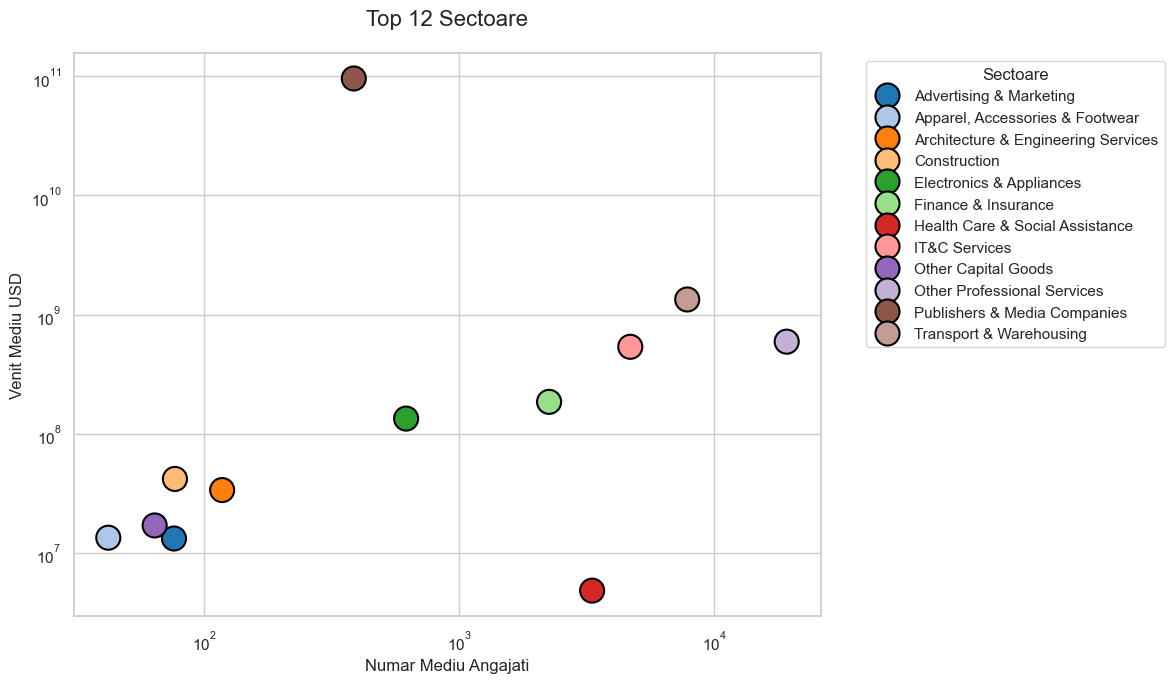

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('best_selection_cleaned.csv')

top_12_sectors = df['main_sector'].value_counts().nlargest(12).index
df_top12 = df[df['main_sector'].isin(top_12_sectors)].copy()

sector_stats = df_top12.groupby('main_sector').agg({
    'revenue': 'mean',
    'employee_count': 'mean'
}).reset_index()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

scatter = sns.scatterplot(
    data=sector_stats, 
    x='employee_count', 
    y='revenue', 
    hue='main_sector',
    s=300, 
    palette='tab20',
    edgecolor='black',
    linewidth=1.5
)

plt.yscale('log')
plt.xscale('log')

plt.title('Top 12 Sectoare', fontsize=16, pad=20)
plt.xlabel('Numar Mediu Angajati', fontsize=12)
plt.ylabel('Venit Mediu USD', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Sectoare')

plt.tight_layout()
plt.savefig('top_12_sectoare.png', dpi=300)
plt.show()